In [1]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
sns.set_style('dark')

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.

Hence, we developped a function that automatically defines the mask, compute sisal and itrace variograms and save the results.

In [21]:
params = {'trend': 'multiple_linear_ele_latabs',
          'trend_before_mask': True,
          'maxlag': 1.2e7,
          'nlags': 20,
          'centers': None,
          'direction': None,
          'tolerance' : 22.5,
          'mask radius [km]': 1000,
          'res [jours]': 365,
          'Itrace simulation spec' : {'time':'20kyrBP',},
          'countries':None
          }
data_cols = {'lat':'lat',
             'lon':'lon',
             'quantity':'d18Op'}

fp = f"../output/variograms/itrace/sim{params['Itrace simulation spec']['time']}/res{params['res [jours]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp) :
    os.makedirs(fp)

verbose =  False

In [22]:
# Load sisal data 
sisal_df = gutils.get_sisal_data_for_kriging(res=int(params['res [jours]']/365),countries=params['countries'],verbose=verbose)
# load itrace data
itrace_data = gutils.get_preprocessed_itrace_data(res=params['res [jours]'],P=True,format='xr',verbose=False,
                                            sim_prefix = 'b.e13.Bi1850C5.f19_g16',
                                            sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
                                            sim_forcings='ice_ghg_orb_wtr',
                                            sim_kyr= int(params['Itrace simulation spec']['time'][:2]),
                                            sim_num='01',
                                            sim_model='clm2.h0',
                                            ) # xr


loading sisal data
sisal dataframe is ready
loading itrace files


#### **Mask iTrace data around SISAL points**

In [ ]:
itrace_df = gutils.get_preprocessed_itrace_data(res=params['res [jours]'],P=True,format='df',verbose=False,
                                            sim_prefix = 'b.e13.Bi1850C5.f19_g16',
                                            sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
                                            sim_forcings='ice_ghg_orb_wtr',
                                            sim_kyr= 20,
                                            sim_num='01',
                                            sim_model='clm2.h0',
                                            ) # pd df

loading itrace files
done


In [14]:
itrace_df

,lat,lon,time,d18Op,P
0,-90.000000,0.0,0.0,-54.612457,10.802584
1,-90.000000,0.0,365.0,-54.206074,10.779403
2,-90.000000,0.0,730.0,-54.812195,9.712364
3,-90.000000,0.0,1095.0,-54.962994,9.686329
4,-90.000000,0.0,1460.0,-54.419994,9.918655
...,...,...,...,...,...
441700,84.315788,340.0,10220.0,-32.633545,37.814575
441701,84.315788,340.0,10585.0,-33.290028,44.008209
441702,84.315788,340.0,10950.0,-33.446968,36.549641
441703,84.315788,340.0,11315.0,-32.902302,36.418587


In [15]:
itrace_masked_df,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df,params['mask radius [km]'],verbose=True) # type:ignore
print(itrace_masked_df)
putils.plot_global_map(data=itrace_masked_df,
                    quantity_col=data_cols['quantity'],
                    title = 'masked itrace data',
                    quantity=data_cols['quantity'],
                    unit='per mil (VSMOW)',
                    proj=False,
                    symbol='square',
                    size=3,
                    lat_col=data_cols['lat'],
                    lon_col=data_cols['lon'])

> computing distances between data points and anchor points
> done
              lat    lon     time      d18Op           P  mask
56100  -48.315788  167.5      0.0  -8.489728  934.736328  True
56101  -48.315788  167.5    365.0  -8.453548  976.774780  True
56102  -48.315788  167.5    730.0  -8.523046  967.768127  True
56103  -48.315788  167.5   1095.0  -8.484364  948.745300  True
56104  -48.315788  167.5   1460.0  -8.479059  966.226440  True
...           ...    ...      ...        ...         ...   ...
211789  84.315788  -20.0  10220.0 -32.633545   37.814575  True
211790  84.315788  -20.0  10585.0 -33.290028   44.008209  True
211791  84.315788  -20.0  10950.0 -33.446968   36.549641  True
211792  84.315788  -20.0  11315.0 -32.902302   36.418587  True
211793  84.315788  -20.0  11680.0 -32.743752   40.366436  True

[87351 rows x 6 columns]


#### **Compute variograms**

In [23]:
for azimuth in [None,0,45,90,135] : #None,0,45,90,135
    print(f'computation dir={azimuth}')
    params['direction']=azimuth
    gutils.iterate_and_aggregate_variograms(data_ds = itrace_data, #type:ignore
                                        fp=fp,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = sisal_df, # type:ignore
                                        verbose = verbose
                                       )

computation dir=None


100%|██████████| 33/33 [00:22<00:00,  1.46it/s]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res365/maxlag12000000nlags20/trend_multiple_linear_ele_latabs/, files vario_df.csv and trend_metrics.json
computation dir=0


100%|██████████| 33/33 [08:51<00:00, 16.11s/it]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res365/maxlag12000000nlags20/trend_multiple_linear_ele_latabs/d0, files vario_df.csv and trend_metrics.json
computation dir=45


...

outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res365/maxlag12000000nlags20/trend_multiple_linear_ele_latabs/d45, files vario_df.csv and trend_metrics.json
computation dir=90


100%|██████████| 33/33 [08:42<00:00, 15.83s/it]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res365/maxlag12000000nlags20/trend_multiple_linear_ele_latabs/d90, files vario_df.csv and trend_metrics.json
computation dir=135


100%|██████████| 33/33 [08:44<00:00, 15.89s/it]

outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res365/maxlag12000000nlags20/trend_multiple_linear_ele_latabs/d135, files vario_df.csv and trend_metrics.json


In [24]:
dict_dfs= {
           'i_all': {'df': pd.read_csv(fp+'vario_df.csv')},
           'i_0': {'df': pd.read_csv(fp+'d0vario_df.csv')},
           'i_45': {'df': pd.read_csv(fp+'d45vario_df.csv')},
           'i_90': {'df': pd.read_csv(fp+'d90vario_df.csv')},
           'i_135': {'df': pd.read_csv(fp+'d135vario_df.csv')}
        }

model_name = 'spherical'

for key in dict_dfs.keys():
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bins=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

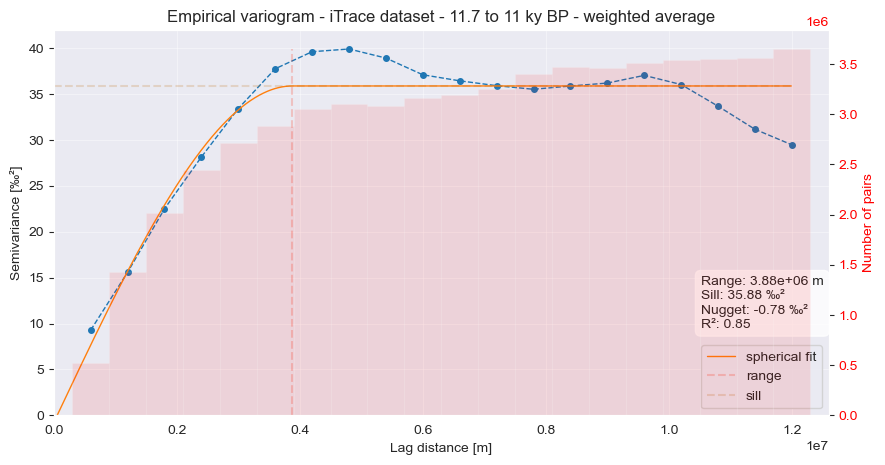

In [25]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['i_all']['df']['lag'],
                                          gamma=dict_dfs['i_all']['df']['gamma'],
                                          time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=dict_dfs['i_all']['df']['count'],
                                          min_pairs=20,
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                          save_name=fp+'fig.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

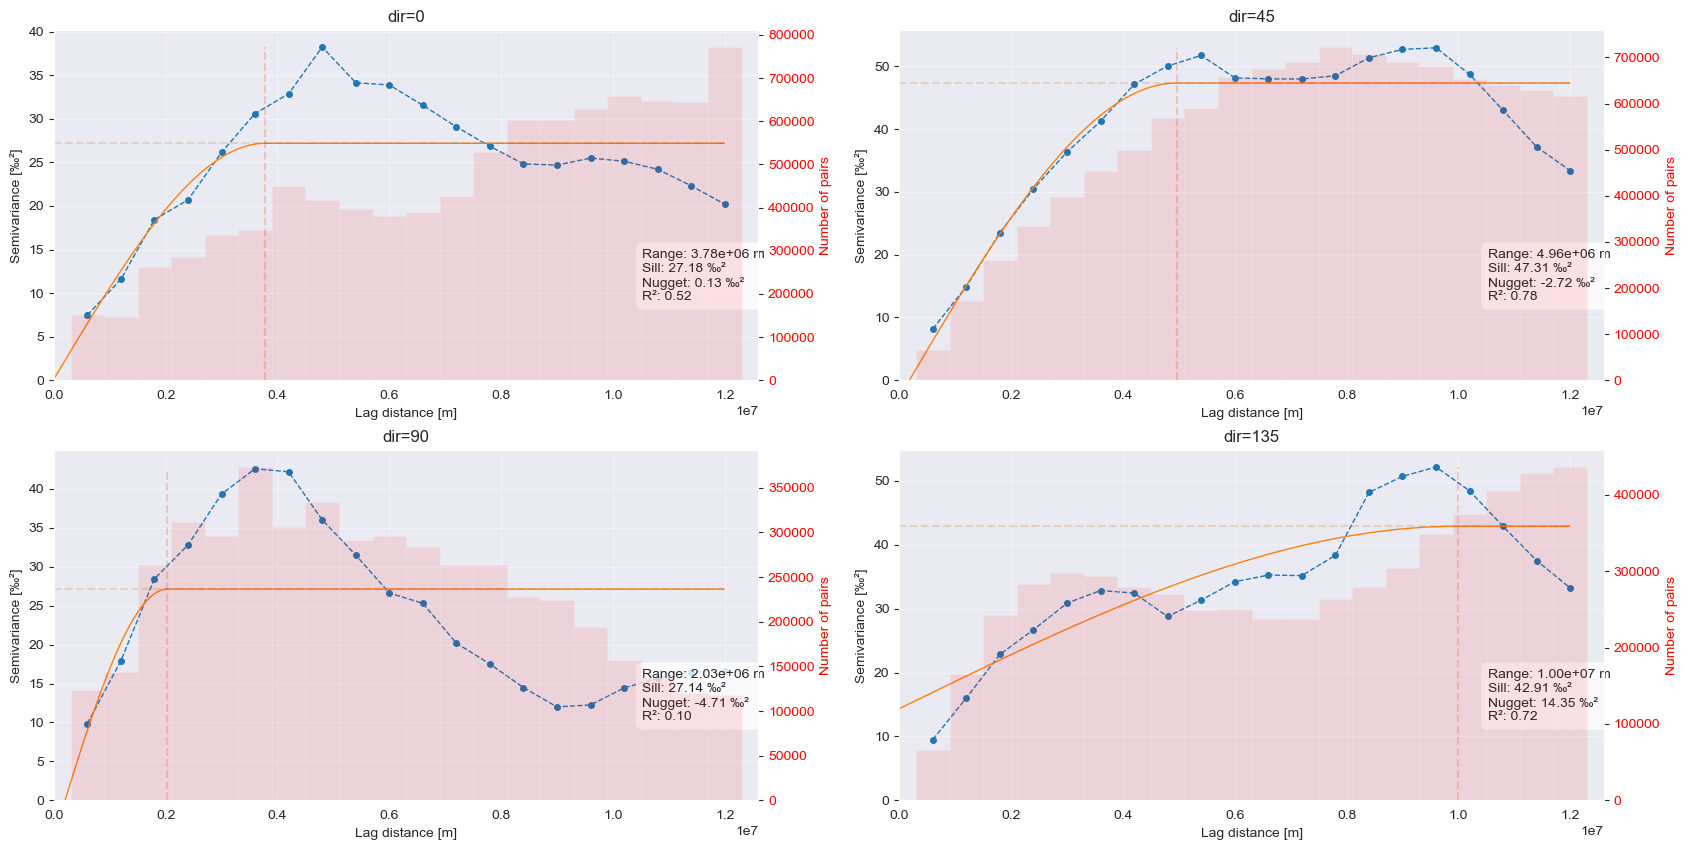

Range in direction 0°: 3.78e+06 m
Range in direction 45°: 4.96e+06 m
Range in direction 90°: 2.03e+06 m
Range in direction 135°: 1.00e+07 m
Anisotropy Ratio: 4.9181001375833215
Anisotropy Direction: 135°


In [26]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs[key]['df']['lag'],
                                                            gamma=dict_dfs[key]['df']['gamma'],
                                                            time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=dict_dfs[key]['df']['count'],
                                                            min_pairs=20,
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r :.2e} m')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')

### Visualize metrics of trend fitting 

In [27]:
import json
with open(fp+'trend_metrics.json', 'r') as f:
    results_dict = json.load(f)

In [28]:
import numpy as np
list_df =[]
metrics_dict = {}
for i,t in enumerate(list(results_dict.keys())):
    df = gutils.multiple_linear_result_dict_to_df(results_dict[t])
    df['time']=float(t)
    df['r2']=results_dict[t]['r2']
    df['r2adj']=results_dict[t]['adj_r2']
    df['mae']=results_dict[t]['mae']
    list_df.append(df)
    


result_df = pd.concat(list_df).reset_index(drop=True)

In [29]:
print(results_dict.keys())

dict_keys(['0.0', '365.0', '730.0', '1095.0', '1460.0', '1825.0', '2190.0', '2555.0', '2920.0', '3285.0', '3650.0', '4015.0', '4380.0', '4745.0', '5110.0', '5475.0', '5840.0', '6205.0', '6570.0', '6935.0', '7300.0', '7665.0', '8030.0', '8395.0', '8760.0', '9125.0', '9490.0', '9855.0', '10220.0', '10585.0', '10950.0', '11315.0', '11680.0'])


In [30]:
result_df[['name','beta','std_error','p_value','vif','r2','r2adj','mae']]

,name,beta,std_error,p_value,vif,r2,r2adj,mae
0,intercept,5.762914,0.172645,5.699226e-225,NaN,0.851625,0.851578,4.757384
1,|lat|,-0.427290,0.003159,0.000000e+00,1.704133,0.851625,0.851578,4.757384
2,ele,-0.006135,0.000075,0.000000e+00,1.704133,0.851625,0.851578,4.757384
3,intercept,5.799893,0.169795,1.251330e-234,NaN,0.856057,0.856011,4.679368
4,|lat|,-0.429781,0.003107,0.000000e+00,1.704133,0.856057,0.856011,4.679368
...,...,...,...,...,...,...,...,...
94,|lat|,-0.431657,0.003152,0.000000e+00,1.704133,0.853147,0.853100,4.755803
95,ele,-0.006074,0.000075,0.000000e+00,1.704133,0.853147,0.853100,4.755803
96,intercept,5.705937,0.170271,1.392343e-226,NaN,0.855671,0.855625,4.699559
97,|lat|,-0.429595,0.003116,0.000000e+00,1.704133,0.855671,0.855625,4.699559
